In [ ]:
# ============================================================
# CONFIGURACION DE CREDENCIALES (HIBRIDO: COLAB SECRETS / LOCAL TXT)
# ============================================================
import os

def load_credentials():
    # 1. Intentar cargar desde Google Colab Secrets (si estamos en Colab)
    try:
        from google.colab import userdata
        keys = ['R2_ACCESS_KEY_ID', 'R2_SECRET_ACCESS_KEY', 'R2_ENDPOINT_URL', 'R2_BUCKET_NAME']
        for k in keys:
            try:
                val = userdata.get(k)
                if val: os.environ[k] = val
            except: pass
    except ImportError:
        pass

    # 2. Si no se cargaron (no estamos en Colab o no hay Secrets), buscar archivo local
    if not os.getenv('R2_ACCESS_KEY_ID'):
        cred_path = '../Keys_and_tokens'
        cred_file = os.path.join(cred_path, 'Credenciales.txt')
        
        if os.path.exists(cred_file):
            with open(cred_file, 'r') as f:
                for line in f:
                    if '=' in line and not line.strip().startswith('#'):
                        parts = line.split('=', 1)
                        key = parts[0].strip()
                        value = parts[1].split('#')[0].strip().strip("'").strip('"')
                        os.environ[key] = value
        else:
            # 3. Si no hay nada, pedir manualmente y guardar
            print(" No se detectaron credenciales (Secrets o TXT).")
            os.makedirs(cred_path, exist_ok=True)
            ak = input("  R2_ACCESS_KEY_ID: ")
            sk = input("  R2_SECRET_ACCESS_KEY: ")
            ep = input("  R2_ENDPOINT_URL: ")
            bn = input("  R2_BUCKET_NAME: ")
            with open(cred_file, 'w') as f:
                f.write(f"R2_ACCESS_KEY_ID = '{ak}'\n")
                f.write(f"R2_SECRET_ACCESS_KEY = '{sk}'\n")
                f.write(f"R2_ENDPOINT_URL = '{ep}'\n")
                f.write(f"R2_BUCKET_NAME = '{bn}'\n")
            os.environ['R2_ACCESS_KEY_ID'] = ak
            os.environ['R2_SECRET_ACCESS_KEY'] = sk
            os.environ['R2_ENDPOINT_URL'] = ep
            os.environ['R2_BUCKET_NAME'] = bn

load_credentials()

R2_ACCESS_KEY_ID     = os.getenv('R2_ACCESS_KEY_ID')
R2_SECRET_ACCESS_KEY = os.getenv('R2_SECRET_ACCESS_KEY')
R2_ENDPOINT_URL      = os.getenv('R2_ENDPOINT_URL')
R2_BUCKET_NAME       = os.getenv('R2_BUCKET_NAME')

CARPETA_DESTINO_R2 = 'estaciones_dagma'
print(f'\n Conectado al Bucket: {R2_BUCKET_NAME}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 26.9 MB/s eta 0:00:00


Extrayendo datos de la nube de Google... esto puede tomar unos segundos.
¡Listo! Se extrajeron 39 días de datos válidos.


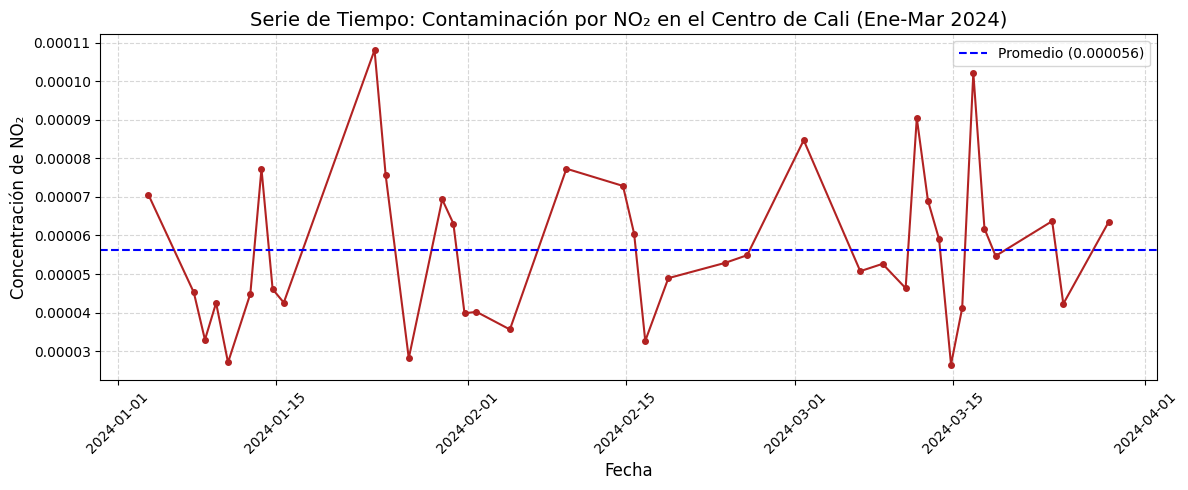


Así se ven los datos tabulares listos para análisis:


,fecha,NO2
34,2024-01-03 17:37:32,0.000071
91,2024-01-07 18:03:04,0.000045
105,2024-01-08 17:44:04,0.000033
119,2024-01-09 17:25:05,0.000042
134,2024-01-10 18:47:36,0.000027


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import ee

# 1. Definimos nuestro punto de muestreo (Coordenadas aproximadas del Centro de Cali)
punto_muestreo = ee.Geometry.Point([-76.53, 3.45])

print("Extrayendo datos de la nube de Google... esto puede tomar unos segundos.")

# 2. Llamamos al satélite y filtramos 3 meses de datos (Enero a Marzo 2024)
s5p_filtrado = (ee.ImageCollection("COPERNICUS/S5P/OFFL/L3_NO2")
                .filterBounds(punto_muestreo)
                .filterDate('2024-01-01', '2024-03-31')
                .select('tropospheric_NO2_column_number_density'))

# 3. EL MUESTREO: Usamos la función getRegion para convertir los píxeles en una tabla
# 'scale=1000' significa que tomamos un radio de 1km alrededor del punto
datos_crudos = s5p_filtrado.getRegion(punto_muestreo, scale=1000).getInfo()

# 4. Convertimos la respuesta de Google en un DataFrame (Tabla) de Pandas
# La primera fila (datos_crudos[0]) tiene los nombres de las columnas
df = pd.DataFrame(datos_crudos[1:], columns=datos_crudos[0])

# 5. LIMPIEZA DE DATOS (Mini proceso ETL)
# Convertimos el tiempo (que viene en milisegundos) a una fecha legible
df['fecha'] = pd.to_datetime(df['time'], unit='ms')

# Convertimos el texto a números y eliminamos los días donde el satélite no vio nada (ej. por nubes)
df['NO2'] = pd.to_numeric(df['tropospheric_NO2_column_number_density'], errors='coerce')
df = df.dropna(subset=['NO2'])

print(f"¡Listo! Se extrajeron {len(df)} días de datos válidos.")

# 6. VISUALIZACIÓN ESTADÍSTICA
plt.figure(figsize=(12, 5))
plt.plot(df['fecha'], df['NO2'], marker='o', linestyle='-', color='firebrick', markersize=4)

# Línea de tendencia simple (Promedio del trimestre)
promedio = df['NO2'].mean()
plt.axhline(y=promedio, color='blue', linestyle='--', label=f'Promedio ({promedio:.6f})')

plt.title('Serie de Tiempo: Contaminación por NO₂ en el Centro de Cali (Ene-Mar 2024)', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Concentración de NO₂', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 7. Mostrar las primeras filas de la tabla generada
print("\nAsí se ven los datos tabulares listos para análisis:")
display(df[['fecha', 'NO2']].head())

Extrayendo NO2, SO2 y O3 desde los satélites de Google... (Tardará unos 20 segundos)
¡Listo! 31 días con mediciones perfectas de los 3 gases simultáneamente.



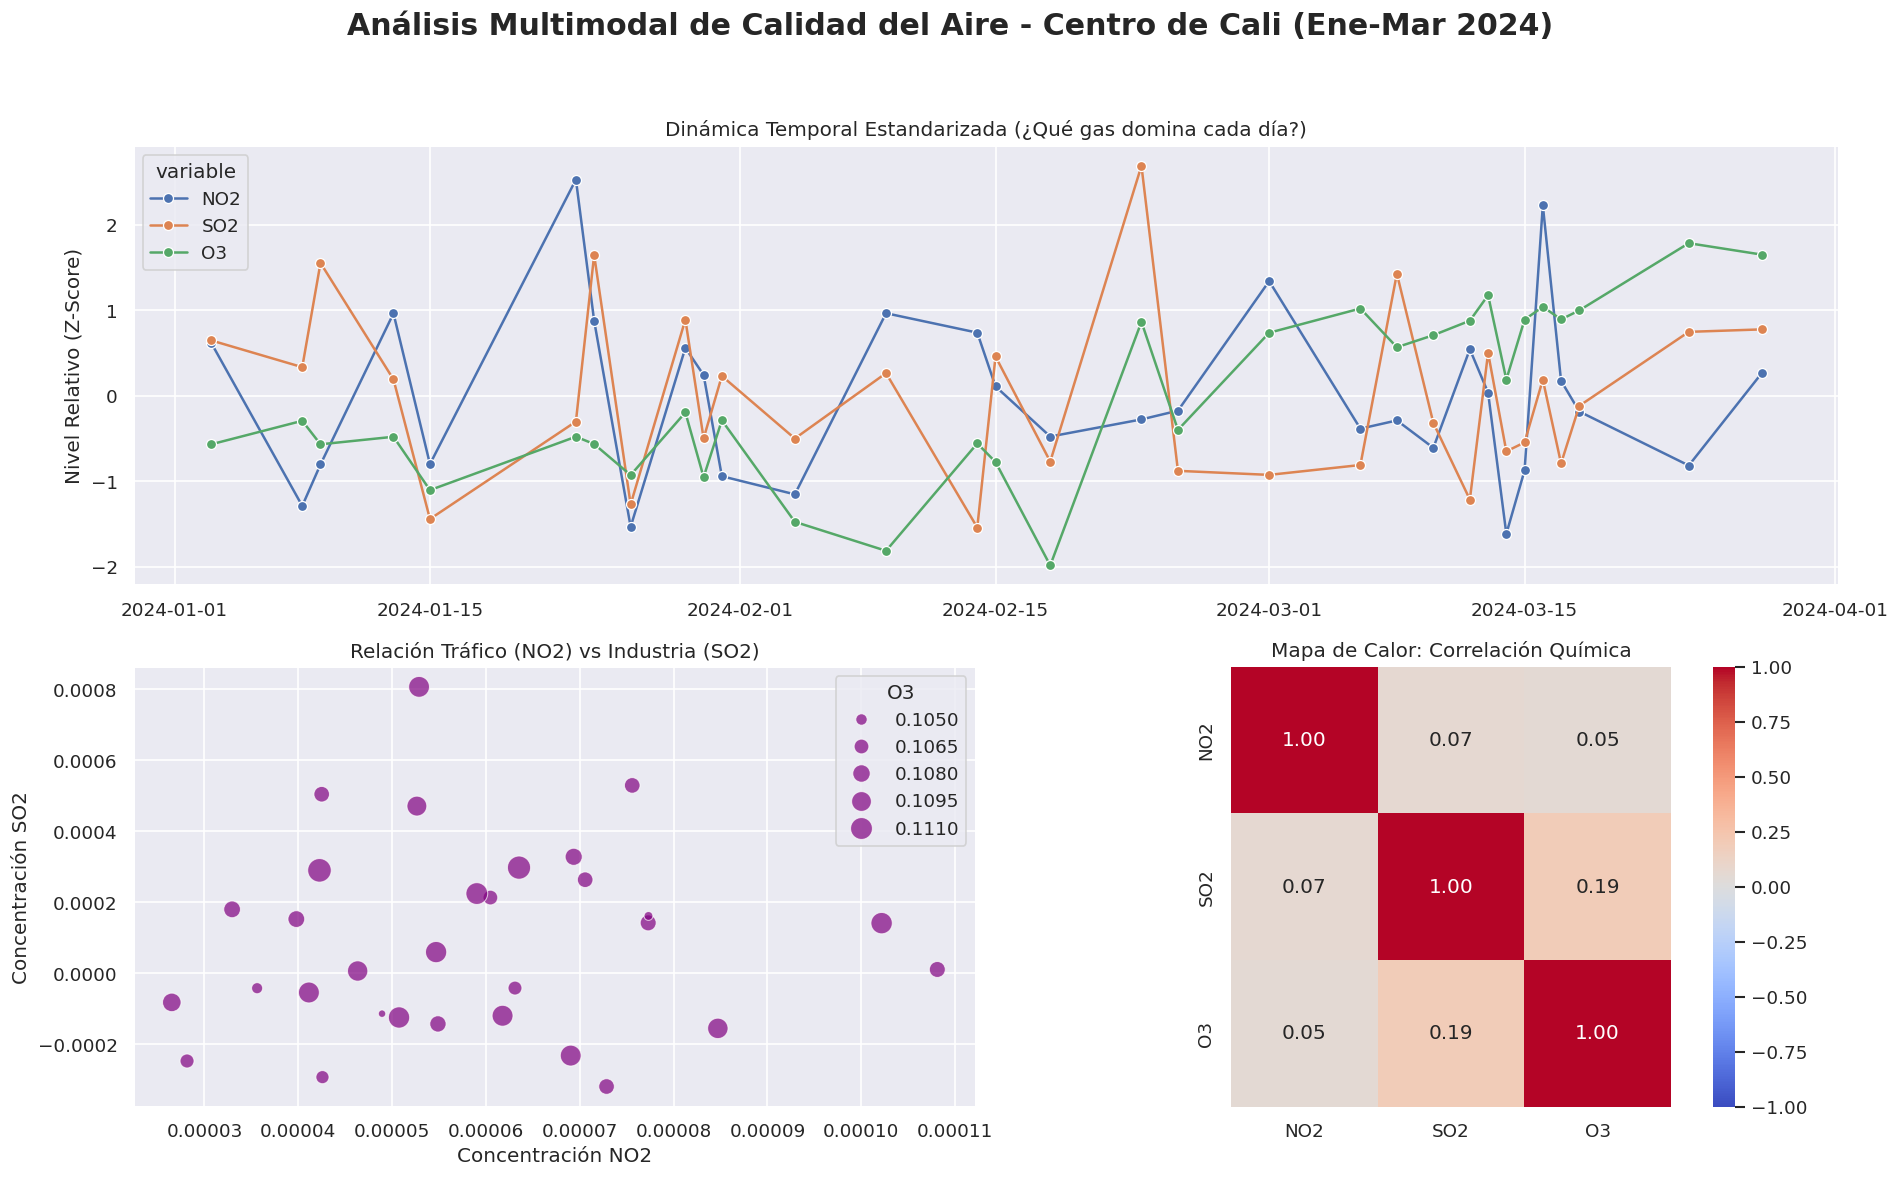

,fecha,NO2,SO2,O3
0,2024-01-03,0.000071,0.000264,0.106959
1,2024-01-08,0.000033,0.000180,0.107589
2,2024-01-09,0.000042,0.000505,0.106960
3,2024-01-13,0.000077,0.000142,0.107162
4,2024-01-15,0.000043,-0.000293,0.105734


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ee

# 1. Configuración de estilo "chido" para las gráficas
sns.set_theme(style="darkgrid", palette="deep")
plt.rcParams['figure.dpi'] = 120 # Gráficas en alta resolución

# 2. Definimos el punto (Centro de Cali) y las fechas
punto_muestreo = ee.Geometry.Point([-76.53, 3.45])
fecha_inicio = '2024-01-01'
fecha_fin = '2024-03-31'

print("Extrayendo NO2, SO2 y O3 desde los satélites de Google... (Tardará unos 20 segundos)")

# 3. Función automatizada para no repetir código por cada gas
def extraer_gas(coleccion, banda, nombre_columna):
    satelite = ee.ImageCollection(coleccion).filterBounds(punto_muestreo).filterDate(fecha_inicio, fecha_fin).select(banda)
    datos = satelite.getRegion(punto_muestreo, scale=1000).getInfo()
    df = pd.DataFrame(datos[1:], columns=datos[0])
    # Limpieza
    df['fecha'] = pd.to_datetime(df['time'], unit='ms').dt.date
    df[nombre_columna] = pd.to_numeric(df[banda], errors='coerce')
    return df[['fecha', nombre_columna]].dropna()

# 4. Descargamos los 3 gases
df_no2 = extraer_gas("COPERNICUS/S5P/OFFL/L3_NO2", 'tropospheric_NO2_column_number_density', 'NO2')
df_so2 = extraer_gas("COPERNICUS/S5P/OFFL/L3_SO2", 'SO2_column_number_density', 'SO2')
df_o3 = extraer_gas("COPERNICUS/S5P/OFFL/L3_O3", 'O3_column_number_density', 'O3')

# 5. Unimos todo en una sola super-tabla usando la fecha como puente
df_final = df_no2.merge(df_so2, on='fecha', how='inner').merge(df_o3, on='fecha', how='inner')
print(f"¡Listo! {len(df_final)} días con mediciones perfectas de los 3 gases simultáneamente.\n")

# ==========================================
# 6. CREACIÓN DEL DASHBOARD VISUAL (GRÁFICAS)
# ==========================================
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Análisis Multimodal de Calidad del Aire - Centro de Cali (Ene-Mar 2024)', fontsize=18, fontweight='bold', y=0.98)

# Gráfica 1: Evolución Temporal Comparativa (Arriba, ocupa todo el ancho)
ax1 = plt.subplot(2, 2, (1, 2))
# Estandarizamos los datos (Z-score) solo para visualizarlos juntos, ya que sus escalas químicas son muy distintas
df_norm = (df_final[['NO2', 'SO2', 'O3']] - df_final[['NO2', 'SO2', 'O3']].mean()) / df_final[['NO2', 'SO2', 'O3']].std()
df_norm['fecha'] = df_final['fecha']
sns.lineplot(data=df_norm.melt(id_vars=['fecha']), x='fecha', y='value', hue='variable', marker='o', ax=ax1)
ax1.set_title('Dinámica Temporal Estandarizada (¿Qué gas domina cada día?)')
ax1.set_ylabel('Nivel Relativo (Z-Score)')
ax1.set_xlabel('')

# Gráfica 2: Dispersión NO2 vs SO2 (Abajo izquierda)
ax2 = plt.subplot(2, 2, 3)
sns.scatterplot(data=df_final, x='NO2', y='SO2', size='O3', sizes=(20, 200), alpha=0.7, color='purple', ax=ax2)
ax2.set_title('Relación Tráfico (NO2) vs Industria (SO2)')
ax2.set_xlabel('Concentración NO2')
ax2.set_ylabel('Concentración SO2')

# Gráfica 3: Matriz de Correlación (Abajo derecha) - ¡Esta le encanta a los profesores!
ax3 = plt.subplot(2, 2, 4)
correlacion = df_final[['NO2', 'SO2', 'O3']].corr()
sns.heatmap(correlacion, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True, ax=ax3, fmt='.2f')
ax3.set_title('Mapa de Calor: Correlación Química')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Mostrar la tabla final
display(df_final.head())